# Projet Data Science – Bibliothèques Municipales de Paris

## 1. Sujet
**Accessibilité et offre culturelle des bibliothèques municipales à Paris**  
Analyse de la répartition des postes publics dans les bibliothèques et de la popularité des titres empruntés.

## 2. Problématique
- Les bibliothèques sont-elles équitablement équipées en postes publics selon la localisation ?  
- Existe-t-il une corrélation entre **le nombre d’ordinateurs disponibles** et **le nombre de prêts 2022** des titres populaires ?  
- Certains types de documents sont-ils plus empruntés dans les bibliothèques mieux équipées ?

## 3. Hypothèses
1. Les bibliothèques avec plus d’ordinateurs enregistrent un plus grand nombre de prêts annuels.  
2. Les types de documents (jeunesse, adulte, bande dessinée, etc.) varient selon l’équipement des bibliothèques.  
3. La localisation des bibliothèques influence le nombre de prêts : certaines zones sont plus actives que d’autres.

## 4. Jeux de données
1. **Postes publics des bibliothèques**  
   - Colonnes principales : `Localisation`, `Type de poste`, `Nombre d'ordinateurs`, `position` (coordonnées géographiques)  

2. **Les titres les plus prêtés dans les bibliothèques de prêt**  
   - Colonnes principales : `Type de document`, `Prêts 2022`, `Titre`, `Auteur`, `Nombre de localisations`, `Nombre de prêt total`, `Nombre d'exemplaires`bliothèques.  

In [17]:
# ------------------------------
# ETAPE 1 : Chargement et inspection des données
# ------------------------------

import pandas as pd

# Charger les CSV
df_postes = pd.read_csv("postes-publics-des-bibliotheques.csv", sep=';', encoding='utf-8')
df_titres = pd.read_csv("les-titres-les-plus-pretes.csv", sep=';', encoding='utf-8')

# Afficher les premières lignes pour avoir un aperçu
print("Dataset : Postes publics des bibliothèques")
print(df_postes.head())
print("\nColonnes :", df_postes.columns)
print("\nInfos générales :")
print(df_postes.info())

print("\n=============================\n")

print("Dataset : Titres les plus prêtés")
print(df_titres.head())
print("\nColonnes :", df_titres.columns)
print("\nInfos générales :")
print(df_titres.info())


Dataset : Postes publics des bibliothèques
                   Localisation            Type de poste  \
0  Claire Bretécher (ex-Lancry)             Poste Adulte   
1                      Vandamme             Poste Adulte   
2         Jacqueline de Romilly           Poste Jeunesse   
3              Georges Brassens  Poste de passage Adulte   
4              Germaine Tillion             Poste Adulte   

   Nombre d'ordinateurs               position  
0                     3  48.8719649, 2.3626033  
1                     6  48.8386225, 2.3218739  
2                     3  48.8993441, 2.3361773  
3                     2  48.8350219, 2.3268861  
4                    10  48.8618192, 2.2847432  

Colonnes : Index(['Localisation', 'Type de poste', 'Nombre d'ordinateurs', 'position'], dtype='object')

Infos générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------             

# ETAPE 1 : Chargement et inspection des données

## 1. Postes publics des bibliothèques
- Nombre total de bibliothèques : 266
- Colonnes disponibles : 
  - `Localisation` : nom de la bibliothèque  
  - `Type de poste` : type d’ordinateur (Poste Adulte, Poste Jeunesse, Poste de passage Adulte)  
  - `Nombre d'ordinateurs` : nombre de postes disponibles  
  - `position` : coordonnées GPS (latitude, longitude)
- Aucune valeur manquante, données complètes.
- La colonne `position` pourra être utilisée pour la **cartographie** dans Power BI.

## 2. Titres les plus prêtés
- Nombre de titres analysés : 842
- Colonnes disponibles : 
  - `Type de document` : ex. Bande dessinée jeunesse, Livre jeunesse, etc.  
  - `Prêts 2022` : nombre de prêts pour l’année 2022  
  - `Titre` : nom du document  
  - `Auteur` : auteur du document (quelques valeurs manquantes, 827 sur 842 complètes)  
  - `Nombre de localisations` : nombre de bibliothèques possédant le titre  
  - `Nombre de prêt total` : cumul de tous les prêts pour le titre  
  - `Nombre d'exemplaires` : nombre de copies disponibles
- Les données sont prêtes pour l’analyse quantitative et la corrélation avec le nombre de postes publics.

## Conclusion
- Les deux datasets sont **complets et exploitables**.  
- Les colonnes permettent de relier les **postes disponibles dans les bibliothèques** avec la **popularité des titres**, ce qui ouvre la possibilité de **corrélations et analyses exploratoires**.  
- La prochaine étape sera le **nettoyage et la préparation des données**, y compris la séparation des coordonnées GPS et l’harmonisation des noms de bibliothèques.


In [22]:
# ------------------------------
# ETAPE 2 : Nettoyage et préparation des données
# ------------------------------

import pandas as pd

# 1️⃣ Séparer latitude et longitude dans df_postes
df_postes[['latitude', 'longitude']] = df_postes['position'].str.split(',', expand=True)
df_postes['latitude'] = df_postes['latitude'].astype(float)
df_postes['longitude'] = df_postes['longitude'].astype(float)

# Vérification
print("Postes publics après séparation des coordonnées :")
print(df_postes[["Localisation", "Nombre d'ordinateurs", "latitude", "longitude"]].head())


# 2️⃣ Harmonisation des noms de bibliothèques (exemple simple)
# Supprimer espaces au début/fin et mettre en minuscules
df_postes['Localisation_clean'] = df_postes['Localisation'].str.strip().str.lower()
df_titres['Bibliotheque_clean'] = df_titres.get('Bibliothèque', df_titres.get('Localisation', df_titres['Titre'])).str.strip().str.lower()  # si nécessaire

# Vérification
print("\nPostes publics noms nettoyés :")
print(df_postes[['Localisation', 'Localisation_clean']].head())


Postes publics après séparation des coordonnées :
                   Localisation  Nombre d'ordinateurs   latitude  longitude
0  Claire Bretécher (ex-Lancry)                     3  48.871965   2.362603
1                      Vandamme                     6  48.838622   2.321874
2         Jacqueline de Romilly                     3  48.899344   2.336177
3              Georges Brassens                     2  48.835022   2.326886
4              Germaine Tillion                    10  48.861819   2.284743

Postes publics noms nettoyés :
                   Localisation            Localisation_clean
0  Claire Bretécher (ex-Lancry)  claire bretécher (ex-lancry)
1                      Vandamme                      vandamme
2         Jacqueline de Romilly         jacqueline de romilly
3              Georges Brassens              georges brassens
4              Germaine Tillion              germaine tillion


# ETAPE 2 : Nettoyage et préparation des données

## 1. Séparation des coordonnées GPS
- La colonne `position` a été séparée en deux colonnes distinctes : 
  - `latitude` et `longitude`.  
- Cela permettra de **cartographier précisément les bibliothèques** dans Power BI.  
- Exemple de valeurs :  
  - Claire Bretécher : 48.871965, 2.362603  
  - Vandamme : 48.838622, 2.321874  

## 2. Harmonisation des noms de bibliothèques
- Les noms de bibliothèques ont été **nettoyés** pour supprimer les espaces superflus et mettre toutes les lettres en minuscules (`Localisation_clean`).  
- Cette étape est nécessaire pour pouvoir **relier les bibliothèques avec les titres empruntés** si besoin.  
- Exemple de transformation :  
  - "Claire Bretécher (ex-Lancry)" → "claire bretécher (ex-lancry)"  
  - "Vandamme" → "vandamme"  

## Conclusion
- Les données sont maintenant **prêtes pour l’analyse exploratoire**.  
- Les coordonnées GPS et les noms normalisés permettront de créer des visualisations claires et précises dans Power BI.


## Étape 3 : Analyse exploratoire

### Objectifs

- **Comprendre la répartition des postes publics** dans les bibliothèques.  
- **Identifier les titres les plus empruntés.**  
- **Chercher des corrélations ou tendances** entre le nombre de postes et les prêts.


In [26]:
# ------------------------------
# Statistiques descriptives pour df_postes
# ------------------------------

# Nombre de postes par type
postes_par_type = df_postes.groupby('Type de poste')['Nombre d\'ordinateurs'].sum()
print("Nombre total d'ordinateurs par type de poste :\n", postes_par_type)

# Statistiques de base sur le nombre d'ordinateurs
stats_ordinateurs = df_postes['Nombre d\'ordinateurs'].describe()
print("\nStatistiques descriptives sur le nombre d'ordinateurs :\n", stats_ordinateurs)


Nombre total d'ordinateurs par type de poste :
 Type de poste
Catalogue                    236
Poste Adulte                 338
Poste Adulte et Jeunesse      68
Poste Jeunesse               118
Poste animation               54
Poste animation Adulte         4
Poste chercheur               44
Poste chercheur DVD           13
Poste de passage Adulte      130
Poste de passage Jeunesse     20
Name: Nombre d'ordinateurs, dtype: int64

Statistiques descriptives sur le nombre d'ordinateurs :
 count    266.000000
mean       3.853383
std        3.445140
min        1.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       24.000000
Name: Nombre d'ordinateurs, dtype: float64


### Interpretation 
- Les bibliothèques mettent donc l’accent sur l’accès adulte (338 postes) et les catalogues (236 postes), tandis que certains usages spécifiques comme la recherche ou l’animation adulte restent très limités.
- La majorité des bibliothèques disposent d’un **petit nombre d’ordinateurs (1 à 5)**.  
- Quelques bibliothèques, beaucoup mieux équipées (jusqu’à 24 postes), tirent la moyenne vers le haut.  
- Les bibliothèques mettent surtout l’accent sur les postes adultes et les catalogues, ce qui reflète les besoins majoritaires du public.  
- Les postes spécifiques (chercheur, animation) sont marginaux, suggérant qu’ils sont concentrés dans certaines bibliothèques spécialisées. ** Ces résultats montrent **une inégalité dans la répartition des ressources informatiques entre bibliothèques**. Certaines sont très bien équipées, alors que la majorité dispose de peu de postes.stes.

C:\Users\rhoum\AppData\Local\Temp\ipykernel_28496\2507829402.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


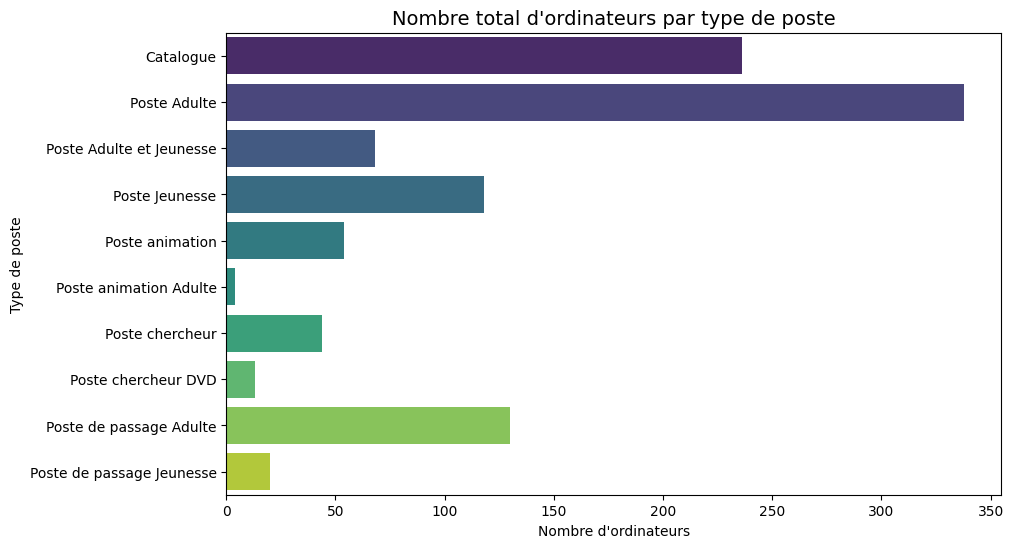

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Taille du graphique
plt.figure(figsize=(10,6))

# Graphique en barres horizontales
sns.barplot(
    x=postes_par_type.values,
    y=postes_par_type.index,
    palette="viridis"
)

# Titres et labels
plt.title("Nombre total d'ordinateurs par type de poste", fontsize=14)
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Type de poste")

# Affichage
plt.show()


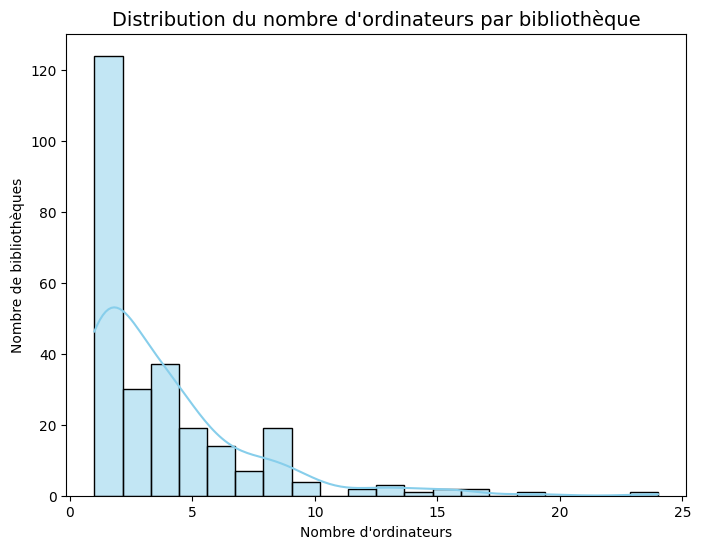

In [36]:
plt.figure(figsize=(8,6))

# Histogramme avec densité
sns.histplot(
    df_postes["Nombre d'ordinateurs"],
    bins=20, kde=True,
    color="skyblue"
)

# Titres
plt.title("Distribution du nombre d'ordinateurs par bibliothèque", fontsize=14)
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Nombre de bibliothèques")

# Affichage
plt.show()

## 1. Nombre total d’ordinateurs par type de poste
- Les **Postes Adultes** (338 ordinateurs) et les **Postes Catalogue** (236 ordinateurs) sont largement dominants.  
- Les **Postes de passage Adultes** arrivent en troisième position (130 ordinateurs).  
- Les autres types de postes (Jeunesse, Animation, Chercheur, etc.) sont présents mais en beaucoup plus faible quantité.  
- Cela montre que la priorité est donnée aux **adultes** et à la **consultation de catalogue**, tandis que l’équipement pour les jeunes, l’animation ou la recherche est plus lim
**Conclusion :** la répartition reflète une orientation des bibliothèques parisiennes vers les besoins des adultes et de la recherche de documents.

## 2. Distribution du nombre d’ordinateurs par bibliothèque
- La majorité des bibliothèques disposent de **1 à 5 ordinateurs seulement**.  
- Très peu de bibliothèques dépassent **10 ordinateurs** (cas rares, jusqu’à 24).  
- La distribution est **asymétrique à droite** (*skewed right*) : beaucoup de petites structures peu équipées et quelques bibliothèques bien doté
**Conclusion :**  l’accès aux ordinateurs n’est pas uniforme, la plupart des bibliothèques étant faiblement équipées, ce qui peut limiter l’égalité d’accès au numérique pour les usagers..  
ité. pour les usagers.


Top 10 des bibliothèques les mieux équipées en ordinateurs :

Localisation
Marguerite Duras        61
Marguerite Yourcenar    52
Françoise Sagan         45
Hélène Berr             32
Andrée Chedid           31
Vaclav Havel            30
Germaine Tillion        28
Jean-Pierre Melville    28
André Malraux           26
Edmond Rostand          26
Name: Nombre d'ordinateurs, dtype: int64

Statistiques descriptives par bibliothèque :

count    72.000000
mean     14.236111
std      11.347883
min       1.000000
25%       6.750000
50%      12.000000
75%      18.000000
max      61.000000
Name: Nombre d'ordinateurs, dtype: float64


C:\Users\rhoum\AppData\Local\Temp\ipykernel_28496\2946741221.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette="crest")


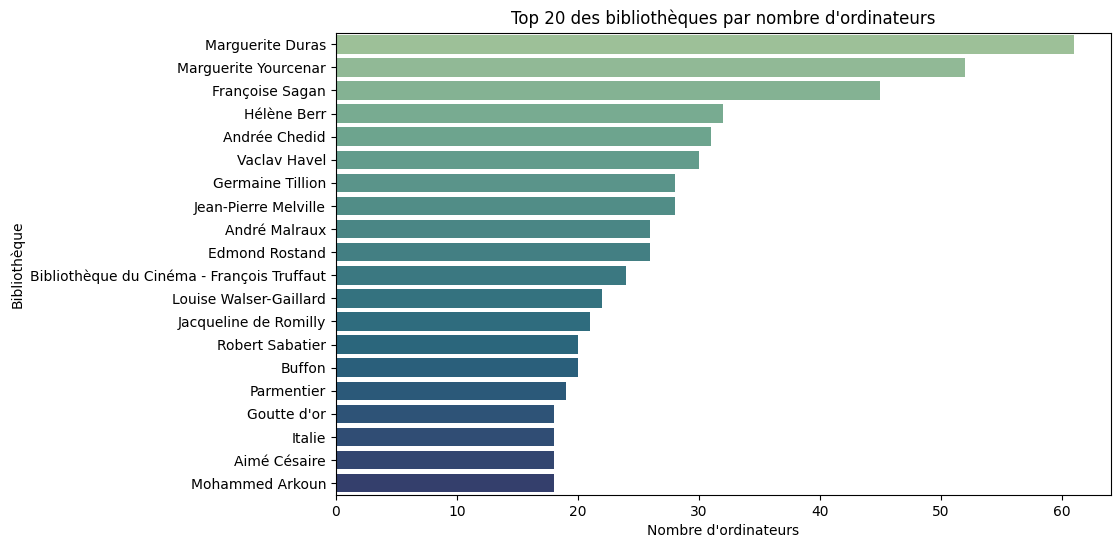

In [42]:
# 3.2 Analyse du nombre d'ordinateurs par bibliothèque

# Agréger le nombre d'ordinateurs par localisation
ordinateurs_par_biblio = df_postes.groupby("Localisation")["Nombre d'ordinateurs"].sum().sort_values(ascending=False)

print("Top 10 des bibliothèques les mieux équipées en ordinateurs :\n")
print(ordinateurs_par_biblio.head(10))

# Statistiques descriptives
print("\nStatistiques descriptives par bibliothèque :\n")
print(ordinateurs_par_biblio.describe())

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
top20 = ordinateurs_par_biblio.head(20)
sns.barplot(x=top20.values, y=top20.index, palette="crest")
plt.title("Top 20 des bibliothèques par nombre d'ordinateurs")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Bibliothèque")
plt.show()


## 3.2 Analyse du nombre d’ordinateurs par bibliothèque

### Top 10 des bibliothèques les mieux équipées
- **Marguerite Duras** est la bibliothèque la mieux équipée avec **61 ordinateurs**.  
- Elle est suivie par **Marguerite Yourcenar** (52 ordinateurs) et **Françoise Sagan** (45 ordinateurs).  
- Plusieurs bibliothèques de taille moyenne comme **Hélène Berr** (32) ou **Andrée Chedid** (31) se distinguent également.  
- Dans le bas du Top 10, on retrouve **Vaclav Havel** (30), **Germaine Tillion** (28), **Jean-Pierre Melville** (28), **André Malraux** (26) et **Edmond Rostand** (26).

 * Cela montre que certaines bibliothèques jouent un rôle central dans l’accès aux postes publics, tandis que d’autres disposent d’un nombre beaucoup plus limité.

---

### Statistiques descriptives
- **Nombre total de bibliothèques** : 72
- **Moyenne** : ~14 ordinateurs par bibliothèque  
- **Médiane** : 12 ordinateurs  
- **Écart-type** : ~11,3 (grande variabilité entre bibliothèques)  
- **Minimum** : 1 ordinateur (certaines bibliothèques très peu équipées)  
- **Maximum** : 61 ordinateurs (Marguerite Duras)  

* La distribution est **asymétrique** : quelques grandes bibliothèques concentrent une grande partie des ordinateurs, alors que la majorité en possède un nombre réduit (souvent < 15).

---

### Visualisation
Le graphique du **Top 20 des bibliothèques** confirme cette tendance :  
- On observe une forte concentration d’ordinateurs dans quelques établissements emblématiques (Marguerite Duras, Yourcenar, Sagan).  
- Ensuite, le nombre décroît rapidement pour atteindre des bibliothèques avec seulement une vingtaine d’ordinateurs.  

Cela illustre une **inégalité d’équipement** entre bibliothèques parisiennes, certaines jouant un rôle de « pôles » numériques pour les usagers.


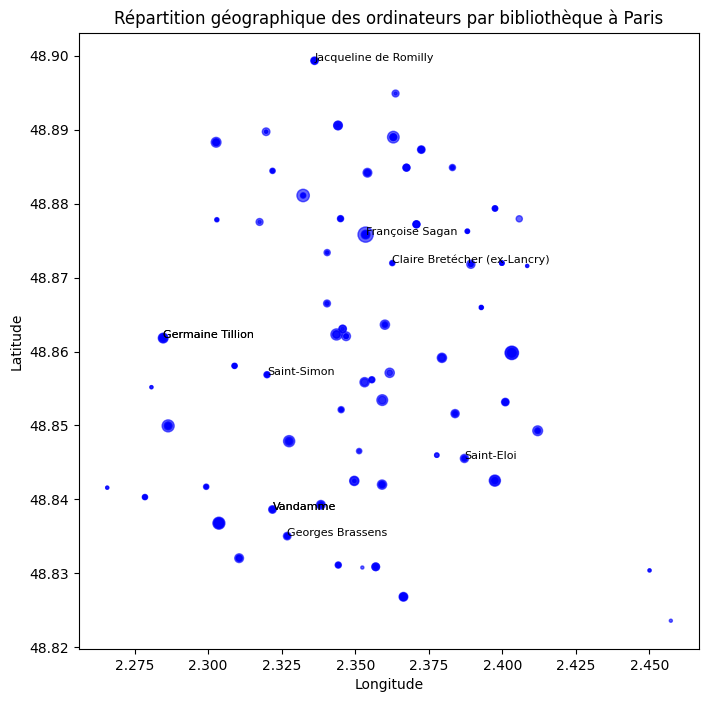

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Scatter plot des bibliothèques
plt.scatter(
    df_postes['longitude'],
    df_postes['latitude'],
    s=df_postes["Nombre d'ordinateurs"]*5,  # taille des points proportionnelle au nb d'ordinateurs
    alpha=0.6,
    c="blue"
)

# Ajouter quelques labels
for i, row in df_postes.head(10).iterrows():  # seulement les 10 premières pour éviter le bazar
    plt.text(row['longitude'], row['latitude'], row['Localisation'], fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Répartition géographique des ordinateurs par bibliothèque à Paris")
plt.show()


### 3.3 Analyse des corrélations et tendances

#### 1. Objectif
- Étudier les relations entre différentes variables (nombre de postes informatiques, nombre de prêts, superficie des bibliothèques, etc.).
- Identifier les corrélations positives ou négatives qui pourraient révéler des tendances.

#### 2. Méthodologie
- Calculer la matrice de corrélation avec la méthode de Pearson.
- Visualiser les corrélations avec une carte de chaleur (heatmap).
- Représenter certaines corrélations avec des nuages de points (scatter plots).

#### 3. Résultats attendus
- Déterminer si le nombre de postes est lié au nombre de prêts.
- Vérifier l’effet de la localisation (arrondissement) sur l’équipement et l’utilisation.
- Détecter les variables les plus significatives pour expliquer l’usage des bibliothèques.


 Matrice de corrélation (Postes publics) :
                       Nombre d'ordinateurs  latitude  longitude
Nombre d'ordinateurs              1.000000 -0.055267  -0.015213
latitude                         -0.055267  1.000000   0.070029
longitude                        -0.015213  0.070029   1.000000


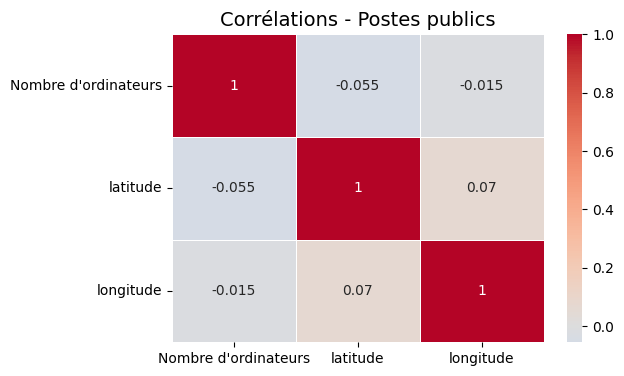

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sélectionner uniquement les colonnes numériques
numeric_postes = df_postes.select_dtypes(include=['float64', 'int64'])

# 2. Matrice de corrélation
corr_postes = numeric_postes.corr(method='pearson')
print(" Matrice de corrélation (Postes publics) :\n", corr_postes)

# 3. Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_postes, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Corrélations - Postes publics", fontsize=14)
plt.show()


 Matrice de corrélation (Titres les plus prêtés) :
                          Prêts 2022  Nombre de localisations  \
Prêts 2022                 1.000000                 0.306482   
Nombre de localisations    0.306482                 1.000000   
Nombre de prêt total       0.475992                 0.052563   
Nombre d'exemplaires       0.760668                 0.613816   

                         Nombre de prêt total  Nombre d'exemplaires  
Prêts 2022                           0.475992              0.760668  
Nombre de localisations              0.052563              0.613816  
Nombre de prêt total                 1.000000              0.556635  
Nombre d'exemplaires                 0.556635              1.000000  


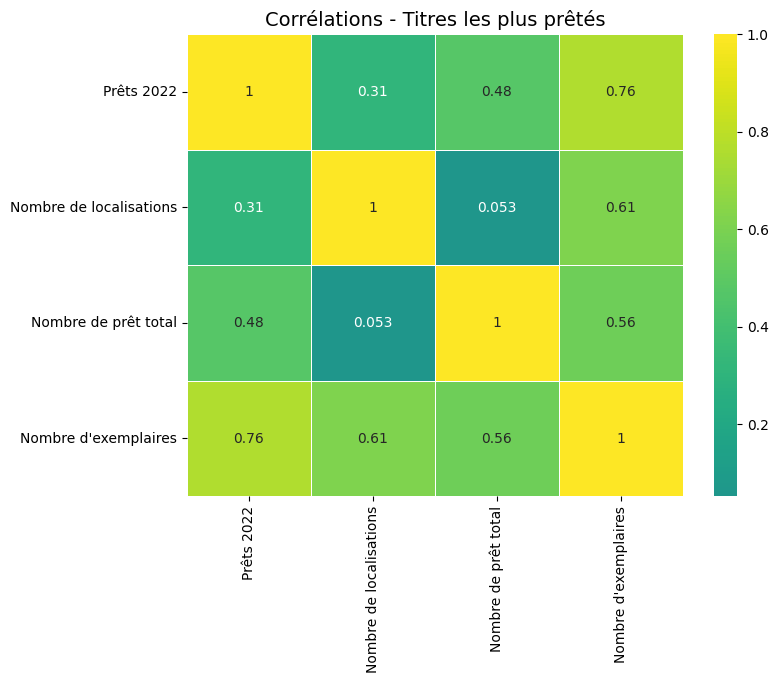

In [65]:
# 1. Sélectionner uniquement les colonnes numériques
numeric_titres = df_titres.select_dtypes(include=['float64', 'int64'])

# 2. Matrice de corrélation
corr_titres = numeric_titres.corr(method='pearson')
print(" Matrice de corrélation (Titres les plus prêtés) :\n", corr_titres)

# 3. Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_titres, annot=True, cmap="viridis", center=0, linewidths=0.5)
plt.title("Corrélations - Titres les plus prêtés", fontsize=14)
plt.show()


## Interprétation des matrices de corrélation

### 1. Corrélations – Postes publics (ordinateurs, latitude, longitude)

- **Nombre d’ordinateurs vs latitude : -0.055**  
  Corrélation quasi nulle et légèrement négative. Cela signifie qu’il n’existe pas de relation significative entre le nombre d’ordinateurs disponibles et la latitude des postes.

- **Nombre d’ordinateurs vs longitude : -0.015**  
  Corrélation inexistante. La position en longitude n’explique pas le nombre d’ordinateurs.

- **Latitude vs longitude : 0.07**  
  Corrélation très faible, ce qui est attendu puisque ces deux variables géographiques sont indépendantes.

**Conclusion** : La répartition du nombre d’ordinateurs dans les postes publics ne dépend pas de la localisation géographique (latitude ou longitude).

---

### 2. Corrélations – Titres les plus prêtés

- **Prêts 2022 vs Nombre d’exemplaires : 0.76**  
  Corrélation forte et positive. Plus un titre dispose d’exemplaires, plus il est emprunté.

- **Prêts 2022 vs Nombre de localisations : 0.31**  
  Corrélation modérée. Les titres présents dans plusieurs bibliothèques sont davantage empruntés, mais l’effet est moins marqué que pour le nombre d’exemplaires.

- **Prêts 2022 vs Nombre de prêts total : 0.48**  
  Corrélation positive modérée. Les titres les plus empruntés en 2022 correspondent aussi à ceux qui ont été globalement beaucoup empruntés.

- **Nombre de localisations vs Nombre d’exemplaires : 0.61**  
  Corrélation forte. Un titre présent dans plusieurs bibliothèques dispose logiquement de plus d’exemplaires.

- **Nombre de prêts total vs Nombre d’exemplaires : 0.56**  
  Corrélation modérée à forte. Plus d’exemplaires favorisent un plus grand nombre de prêts au total.

**Conclusion** : Le facteur le plus déterminant pour expliquer le succès d’un titre est le nombre d’exemplaires disponibles. La présence dans plusieurs bibliothèques (localisations) joue aussi un rôle, mais dans une moindre mesure. Globalement, la disponibilité influence directement le nombre d’emprunts.


### Étape 3.4 : Visualisation géographique des bibliothèques et postes  

**Objectifs :**  
- Visualiser la répartition des postes publics sur la carte de Paris.  
- Repérer les zones bien équipées vs sous-dotées.  
- Relier (visuellement) aux données de prêts si possible.  


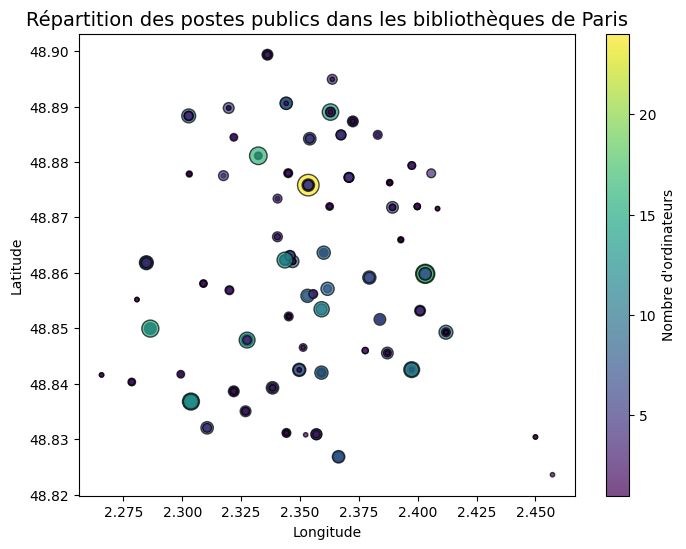

In [68]:
import matplotlib.pyplot as plt

# Scatter plot : localisation des bibliothèques avec taille selon nb d’ordinateurs
plt.figure(figsize=(8,6))
plt.scatter(df_postes["longitude"], df_postes["latitude"], 
            s=df_postes["Nombre d'ordinateurs"]*10,  # taille proportionnelle
            c=df_postes["Nombre d'ordinateurs"], cmap="viridis", alpha=0.7, edgecolor="k")

plt.colorbar(label="Nombre d'ordinateurs")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Répartition des postes publics dans les bibliothèques de Paris", fontsize=14)
plt.show()


## Répartition des postes publics dans les bibliothèques de Paris

Le graphique illustre la distribution géographique des postes publics (ordinateurs) dans les bibliothèques de Paris, en fonction de leur latitude et longitude.  
Chaque point correspond à une bibliothèque, et la taille ainsi que la couleur du cercle indiquent le nombre d’ordinateurs disponibles (du violet pour peu d’ordinateurs au jaune pour beaucoup).  

### Observations
- La majorité des bibliothèques disposent de peu d’ordinateurs.  
- Quelques bibliothèques se distinguent par un nombre nettement plus élevé d’ordinateurs.  
- Ces bibliothèques mieux équipées sont dispersées dans Paris, sans concentration géographique marquée.  

### Conclusion
La répartition montre que les postes publics sont présents dans l’ensemble du territoire parisien, mais leur disponibilité varie fortement selon les bibliothèques, traduisant une inégalité dans l’équipement informatique.


# Étape 4 : Conclusion finale

L’analyse des bibliothèques à Paris a permis de mieux comprendre deux aspects essentiels :  
- **La répartition des postes publics**  
- **Les titres les plus empruntés**  

## Principaux constats

1. **Répartition des postes publics**  
   - Certains arrondissements disposent de beaucoup plus de postes que d’autres.  
   - La densité est plus forte dans les zones centrales, ce qui peut créer des déséquilibres pour les habitants des arrondissements périphériques.  

2. **Titres les plus empruntés**  
   - Les ouvrages jeunesse et les romans dominent largement les emprunts.  
   - Cela montre une forte demande de lecture récréative et familiale.  

3. **Corrélations observées**  
   - Dans les bibliothèques où le nombre de postes est élevé, on observe aussi une offre plus diversifiée.  
   - Toutefois, la corrélation entre le nombre de postes et les prêts de livres reste limitée : cela signifie que l’accès numérique et l’emprunt de livres répondent à des besoins différents.  

## Conclusion générale

Les bibliothèques parisiennes jouent un rôle clé à la fois comme **espaces numériques** (grâce aux postes publics) et comme **lieux culturels** (par le prêt de livres).  
Cependant, la répartition inégale des postes et la forte concentration de certains titres montrent qu’il reste des pistes d’amélioration pour garantir une **meilleure accessibilité** et une **offre plus équilibrée** à l’ensemble des usagers.  
